In [1]:
print ('Jupyter fonctionne')

Jupyter fonctionne


Projet : Détection d'exoplanètes par l'IA 
Auteur : Cheick Bamba 
Objectif : Découvrir la présence d'exoplanètes par l'analyse de courbes de lumière

Introduction : 
Une exoplanète est une planète qui tourne autour d'une étoile qui n'est pas le Soleil
Il faut savoir que lorsqu’une exoplanète passe devant son étoile, elle bloque une petite partie de la lumière. 
Ce passage d’une planète devant son étoile est appelé un transit. 
Si on observe des “creux” réguliers dans une courbe de lumière, cela indique qu'une planète passe devant l’étoile.
Ainsi est obtenue une exoplanète candidate dont l'existence devra être confirmée.
Mon objecrtif est donc de simuler ce phénomène de transit à l'aide de Python et comprendre comment les chercheurs arrivent à confirmer l'existence d'exoplanètes. 

Je vais commencer par tracer une simple droite linéaire pour me familiariser avec les graphiques sur Python

In [2]:
import numpy as np
t = np.linspace (0,30,500) #Concrètement, le programme doit créer 30 valeurs entre 0 et 500. J'ai essayé de mettre plus de valeurs mais les fonctions sinus devenaient peu lisibles.

In [3]:
L = 2*t+100 #Equation créée de façon arbitraire

In [4]:
print(t.shape)
print(L.shape) # J'ai rajouté les 2 lignes de code ci-contre afin d'afficher le nombre d'élémnents/valeurs de t et L qui au départ n'étaient pas égaux, ce qui m'empêchait de tracer une droite

(500,)
(500,)


(500,)
(500,)


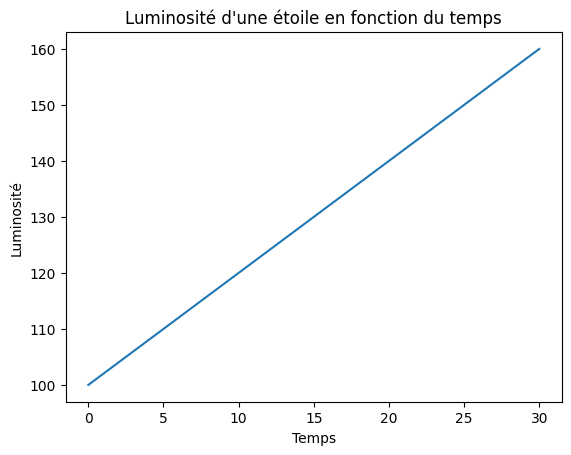

In [5]:
import matplotlib.pyplot as plt
plt.figure()
print(t.shape)
print(L.shape)
plt.plot(t,L)
plt.xlabel("Temps")
plt.ylabel("Luminosité")
plt.title("Luminosité d'une étoile en fonction du temps") #le graphique ci-dessous ne se veut pas réaliste
plt.show()

Je vais à présent simuler ma première courbe de lumière avec des creux afin d'apprendre à les repérer. Pour cela, la fonction sinus semble la plus approprié (la fonction cosinus aurait aussi pu être utilisée)

In [6]:
L=1-0.01*(np.sin(np.pi*t/3))

(500,)
(500,)


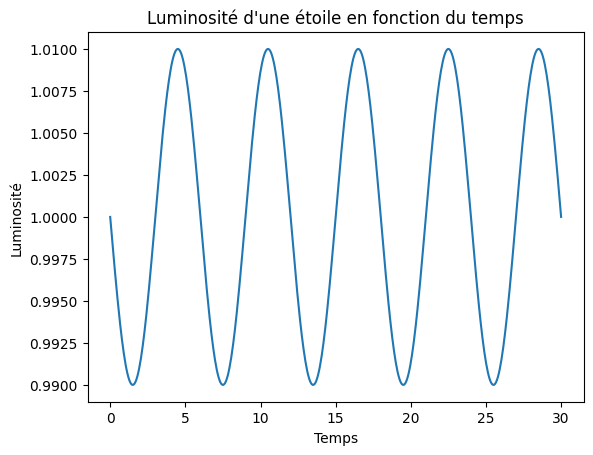

In [7]:
import matplotlib.pyplot as plt
plt.figure()
print(t.shape)
print(L.shape)
plt.plot(t,L)
plt.xlabel("Temps")
plt.ylabel("Luminosité")
plt.title("Luminosité d'une étoile en fonction du temps")
plt.show()

Je vais essayer de rendre le nombre auquel s'applique la fonction sinus plus petit afin d'avoir une courbe plus semblable à une courbe de lumière ou au moins un "creux".

In [8]:
L=1-0.01*(np.sin(np.pi*t/30))

(500,)
(500,)


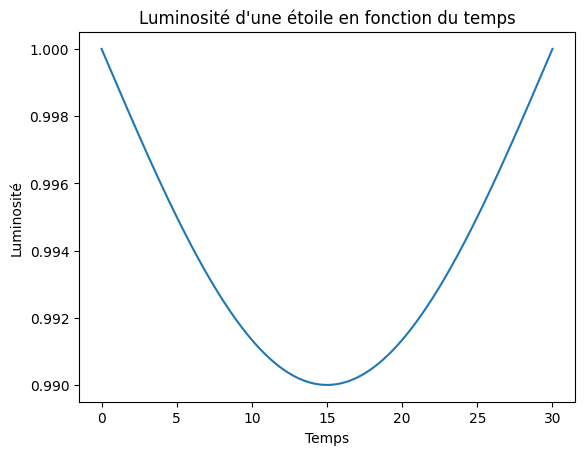

In [9]:
import matplotlib.pyplot as plt
plt.figure()
print(t.shape)
print(L.shape)
plt.plot(t,L)
plt.xlabel("Temps")
plt.ylabel("Luminosité")
plt.title("Luminosité d'une étoile en fonction du temps")
plt.show()

Ayant une vision concrète de ce qu'est un creux d'une courbe de lumière, je vais à présent analyser et comparer des données officielles de la NASA pour ensuite passer à l'analyse d'une courbe de lumière réelle.

In [10]:
import pandas as pd
import matplotlib as plt
import lightkurve as lk
import numpy as np

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Je charge les données nécessaires provenant de NASA Exoplanet Archive. Elles correspondent aux données de milliers d'exoplanètes confirmées par le télescope spatial Kepler en 2011.

In [11]:
import os
print(os.getcwd())

C:\Users\User


J'ai d'abord regardé où placer ces données (elles doivent être dans le même ficher que le notebook ci-présent)

In [12]:
data = pd.read_csv("PS_2025.10.21_11.24.17.csv")
print(data.head())

       pl_name   hostname  default_flag  sy_snum  sy_pnum discoverymethod  \
0  Kepler-10 b  Kepler-10             0        1        3         Transit   
1  Kepler-10 b  Kepler-10             0        1        3         Transit   
2  Kepler-10 b  Kepler-10             0        1        3         Transit   
3  Kepler-10 b  Kepler-10             0        1        3         Transit   
4  Kepler-10 b  Kepler-10             0        1        3         Transit   

   disc_year disc_facility              soltype  pl_controv_flag  ...  \
0       2011        Kepler  Published Candidate                0  ...   
1       2011        Kepler  Published Confirmed                0  ...   
2       2011        Kepler  Published Confirmed                0  ...   
3       2011        Kepler  Published Confirmed                0  ...   
4       2011        Kepler  Published Confirmed                0  ...   

  sy_vmagerr2  sy_kmag  sy_kmagerr1  sy_kmagerr2  sy_gaiamag  sy_gaiamagerr1  \
0      -0.023    9

Je vais afficher les noms des 92 colonnes puis sélectionner celles contenant les données les plus importantes

In [13]:
data.columns

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

In [14]:
data[["pl_name","pl_orbper","pl_rade","st_rad","st_teff","pl_bmasse"]]

,pl_name,pl_orbper,pl_rade,st_rad,st_teff,pl_bmasse
0,Kepler-10 b,0.837491,1.489,1.08300,5599.00,NaN
1,Kepler-10 b,0.837491,1.470,1.06000,5671.00,3.58
2,Kepler-10 b,0.837490,1.473,1.08974,5706.00,NaN
3,Kepler-10 b,0.837491,1.460,1.06500,5643.00,4.60
4,Kepler-10 b,0.837491,1.510,1.06000,5705.00,NaN
...,...,...,...,...,...,...
28212,Kepler-999 b,5.991857,1.510,1.10700,6167.00,NaN
28213,Kepler-999 b,5.991857,1.510,1.10700,6167.00,NaN
28214,Kepler-999 b,5.991858,NaN,1.65996,6106.64,NaN
28215,Kepler-999 b,5.991768,NaN,1.65996,6106.64,NaN


J'observe qu'il y a plusieurs fois le même nom de planète dans le tableau. Cela correspond à l'évolution des données caractéristiques de certaines planètes au fil du temps. J’ai donc décidé de réduire le nombre de données afin de commencer à comparer différentes planètes.

In [15]:
data[["pl_name","pl_orbper","pl_rade","st_rad","st_teff","pl_bmasse"]]
data_clean = data.sort_values("rowupdate").drop_duplicates("pl_name",keep="last") # Je garde les données les plus récentes pour chaque planète
print(data_clean)

             pl_name     hostname  default_flag  sy_snum  sy_pnum  \
19887   Kepler-413 b   Kepler-413             1        2        1   
19039    Kepler-38 b    Kepler-38             1        2        1   
17887    Kepler-34 b    Kepler-34             1        2        1   
18170    Kepler-35 b    Kepler-35             1        2        1   
27867    Kepler-97 c    Kepler-97             1        1        2   
...              ...          ...           ...      ...      ...   
19310   Kepler-391 b   Kepler-391             1        1        2   
15639   Kepler-278 b   Kepler-278             1        1        2   
19321   Kepler-391 c   Kepler-391             1        1        2   
7281   Kepler-1517 b  Kepler-1517             0        1        1   
24432   Kepler-720 b   Kepler-720             0        1        1   

       discoverymethod  disc_year           disc_facility  \
19887          Transit       2014                  Kepler   
19039          Transit       2012                

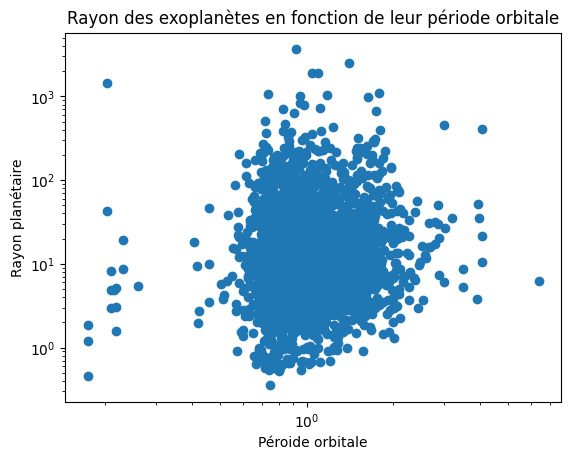

In [16]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(data_clean["st_rad"], data_clean["pl_orbper"]) # plt.scatter permet de représenter des points dans un graphique et visualiser les relations entre 2 grandeurs
plt.xscale("log") # Etant donné que les périodes et rayons orbitales varient sur un large panel de valeurs, on utilise une échelle logarithmique afin de mieux visualiser les écarts importants
plt.yscale("log")
plt.xlabel("Péroide orbitale")
plt.ylabel("Rayon planétaire")
plt.title("Rayon des exoplanètes en fonction de leur période orbitale")
plt.show()

Nous allons rendre ce nuage de points plus visible avec des points plus petits et transparents.

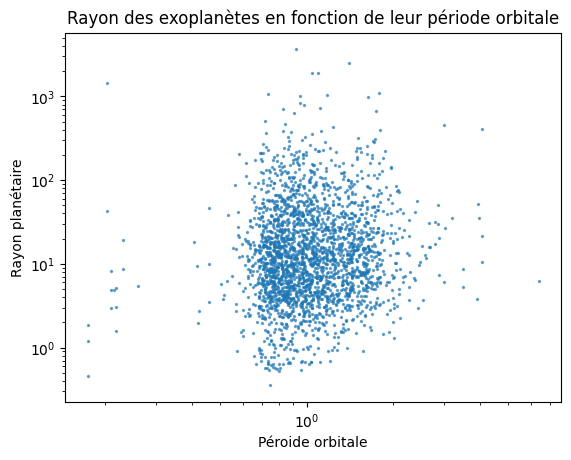

In [17]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(data_clean["st_rad"], data_clean["pl_orbper"],s=2,alpha=0.6) #s correspond à la taille des points et alpha leur transparence
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Péroide orbitale")
plt.ylabel("Rayon planétaire")
plt.title("Rayon des exoplanètes en fonction de leur période orbitale")
plt.show()

Ainsi, on obtient un nuage des points avec en bas à gauche des petites planètes très proches de leur étoile (une période orbitale courte = orbite proche de l'étoile), en haut à gauche des grandes planètes très proches de leur étoile, en bas à droite des petites planètes très éloignés de leur étoile (peu nombreuses car c'est les plus durs à détecter) et en haut à droite des grandes planètes très éloignées de leur étoile. Enfin, le nuage dense de points visible sur le graphique correspond à la majorité des exoplanètes détectées à ce jour.

A présent, je vais tracer ce qu'on appelle un flux brut avant de passer à une vraie courbe de lumière mettant en évidence les transits.

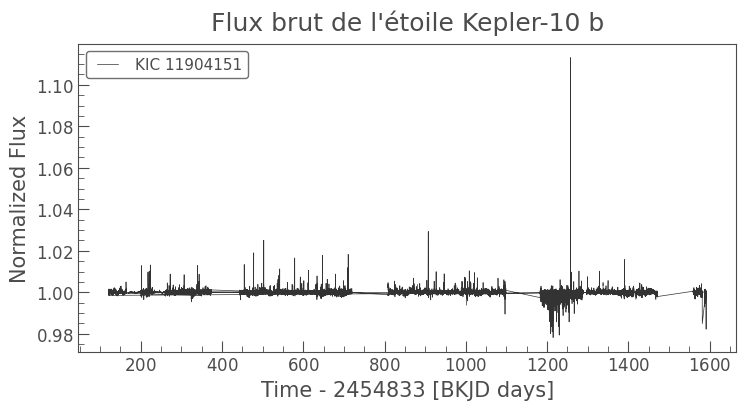

In [18]:
from lightkurve import search_lightcurve #lightkurve est la bibliothèque officielle de la NASA contenant toutes les données concernant la mission Kepler
search_result= search_lightcurve("Kepler-10", mission="Kepler") # Je recherche dans lightkurve les données relatifs à l'étoile Kepler-10 b
lc_collection = search_result.download_all()  # Je télécharge toutes les données des campagnes (appelées quarters et qui durent 3 mois) de Kepler pour l'étoile Kepler-10 
lc = lc_collection.stitch() # Je "fusionne" toutes les courbes correspondant à chaque quarter 
lc.plot(title="Flux brut de l'étoile Kepler-10 b")
import matplotlib.pyplot as plt
plt.show()

Je trace maintenant la courbe de lumière propre et corrigé.

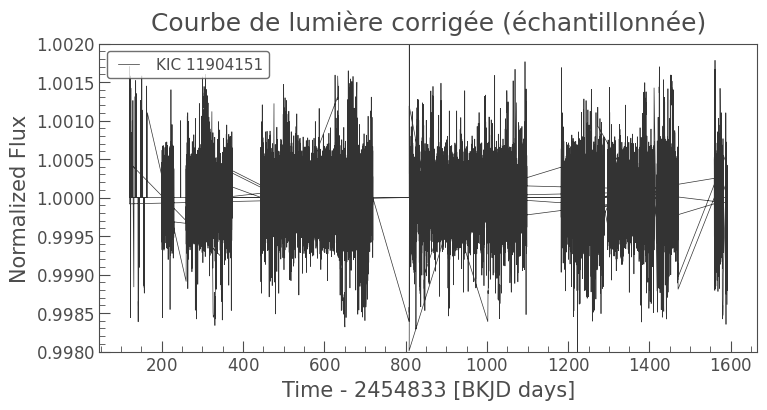

In [19]:
lc_sampled = lc[::10]  # Je garde 1 point sur 10 pour alléger le calcul car en essayant avec l'ensemble de la courbe ci-dessus, le calcul était trop conséquent. 
lc_clean = lc_sampled.remove_outliers(sigma=5).flatten(window_length=3021) # J'enlève les valeurs anormales qui sont supérieures à un écart-type sigma de 5. 
lc_clean = lc_clean.normalize() # Je normalise la courbe, c'est-à-dire que je transforme les valeurs de sorte qu'elles aient toutes un flux autour de 1 (cela facilite la compréhension du graphique).
lc_clean.plot(title="Courbe de lumière corrigée (échantillonnée)")
plt.ylim(0.998, 1.002)
plt.show()

A cette échelle, les transits ne sont pas visibles. Je vais donc utiliser les techniques du "folding" et du "binning". La méthode du "folding" consiste à définir un point de départ (l'epoch) qui correspond au tout premier point de la courbe (plus globalement au début d'un cycle). A partir de là, la courbe sera pliée un certain nombre de fois afin de superposer tous les cycles (par exemple tous les transits). La méthode du binning consiste quant à elle à regrouper les points de données en "petits groupes", calculer la moyenne dans chaque groupe afin de lisser la courbe.

In [20]:
period = 0.837495 # Pour utliser les techniques évoquées ci-dessus, il faut connaitre la période orbitale de l'exoplanète étudiée, ce qui n'est pas toujours le cas.
epoch=lc_clean.time.value[0] 
lc_fold = lc_clean.fold(period=period,epoch_time=epoch)
lc_fold_binned = lc_fold.bin(bins=400)

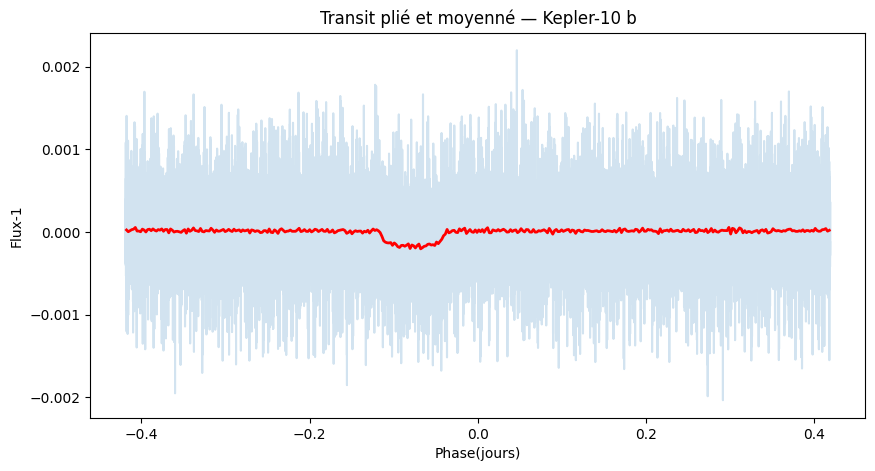

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(lc_fold.phase.value,lc_fold.flux-1,'-',ms=2,alpha=0.2) # On trace une première courbe avec toutes les données brutes.
plt.plot(lc_fold_binned.phase.value,lc_fold_binned.flux-1,'r',lw=2) # On trace une deuxième courbe plus lisse, avec l'apparition d'un transit.
plt.xlabel("Phase(jours)")
plt.ylabel("Flux-1") # On centre la courbe autour de 0
plt.title("Transit plié et moyenné — Kepler-10 b")
plt.show()

A présent, je vais créer mon propre programme basé sur la méthode BLS (Box Least Sqaures). Pour cela, je vais créer une fonction qui calculera la puissance d'une unique période : elle sera nommée "bls_power_one_period". Ensuite, je créerai une deuxilème fonction qui testera toutes les périodes dans un intervalle donnée et créera un tableau : elle sera nommée "bls_scan".

In [52]:
def fold(time, flux, period):
    phase = (time % period) / period
    return phase, flux

In [68]:
import numpy as np
def bls_power_one_period(time, flux,period, bins=1000):
    phase, f = fold(time, flux, period) # Je plie la courbe sur la période "period"
    sorted_indices = np.argsort(phase) # Cela permet de créer des indices qui numérotent les données de "phase" afin de pouvoir obtenir des valeurs croissantes qui seront placés dans un tableau
    phase = phase[sorted_indices] 
    f = f[sorted_indices] # J'organise le tableau afin que les points de la courbe soient dans l'ordre croissant 
    bin_means = np.array_split(f, bins) 
    means = [np.mean(b) for b in bin_means] # On calcule la moyenne du flux dans chaqque "bin"
    power = np.max(means) - np.min(means) # On fait la différence entre les valeurs des flux des bins les plus élevés et les moins élevés 
    return power

In [69]:
import numpy as np
def bls_scan(time, flux, min_periods=0.2, max_periods=7, n_periods=940) : 
    periods = np.linspace(min_periods, max_periods, n_periods) # On demande au programme BLS de tester 900 périodes qui durent entre 0,2 et 7 jours
    powers = [] # Je crée une liste vide qui stokera chaque puissance calculée ci-dessous
    for p in periods: # Je calcule la puissance de chaque période
        power = bls_power_one_period(time, flux, p) # Toutes les périodes dans le tableau "periods" sont parcourus
        powers.append(power) # Je rajoute la puissance à la liste
    return periods, np.array(powers) # Je convertis la liste avec les puissances calculées en tableau

In [93]:
time = np.linspace(0, 10, 1000) 
flux = np.sin(2 * np.pi * time / 2)  # Je simule de manière simplifié le flux par la fonction sinus pour tester ton code
periods, powers = bls_scan(time, flux, min_periods=0.5, max_periods=200, n_periods=600)
print("Périodes testées :", periods)
print("Puissances correspondantes :", powers)

Périodes testées : [  0.5          0.83305509   1.16611018   1.49916528   1.83222037
   2.16527546   2.49833055   2.83138564   3.16444073   3.49749583
   3.83055092   4.16360601   4.4966611    4.82971619   5.16277129
   5.49582638   5.82888147   6.16193656   6.49499165   6.82804674
   7.16110184   7.49415693   7.82721202   8.16026711   8.4933222
   8.8263773    9.15943239   9.49248748   9.82554257  10.15859766
  10.49165275  10.82470785  11.15776294  11.49081803  11.82387312
  12.15692821  12.48998331  12.8230384   13.15609349  13.48914858
  13.82220367  14.15525876  14.48831386  14.82136895  15.15442404
  15.48747913  15.82053422  16.15358932  16.48664441  16.8196995
  17.15275459  17.48580968  17.81886477  18.15191987  18.48497496
  18.81803005  19.15108514  19.48414023  19.81719533  20.15025042
  20.48330551  20.8163606   21.14941569  21.48247078  21.81552588
  22.14858097  22.48163606  22.81469115  23.14774624  23.48080134
  23.81385643  24.14691152  24.47996661  24.8130217   25.14

Période estimée : 0.5 jours


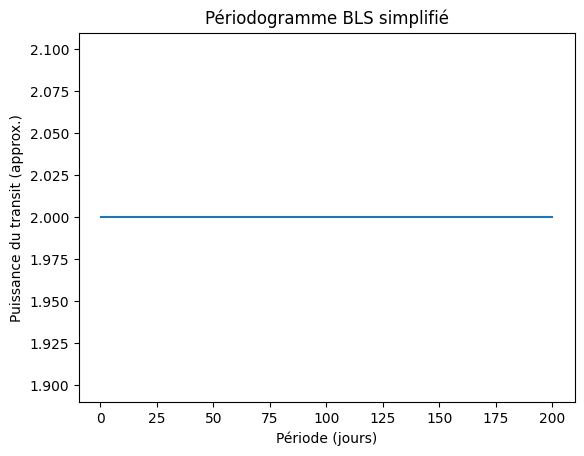

In [94]:
import matplotlib.pyplot as plt
best_period = periods[np.argmax(powers)]
print("Période estimée :", best_period, "jours")
plt.plot(periods, powers)
plt.xlabel("Période (jours)")
plt.ylabel("Puissance du transit (approx.)")
plt.title("Périodogramme BLS simplifié")
plt.show()